# 📊 Data Storytelling — Customer Lifecycle Analysis

---


> **Q1 — Acquisition & First Purchase:** *"Khách hàng đến từ đâu và hành trình từ đăng ký đến lần mua đầu tiên diễn ra như thế nào? Kênh nào mang lại khách hàng có giá trị cao nhất?"*

> **Q2 — Retention, CLV & Churn:** *"Sau lần mua đầu, bao nhiêu % khách hàng quay lại? Phân khúc nào có Lifetime Value cao nhất và ai đang có nguy cơ rời bỏ?"*

---

**Dataset:** E-commerce thời trang Việt Nam | **2012–2022** | 121K khách hàng · 647K đơn hàng · 10 năm vòng đời

---

### Vòng Đời Khách Hàng (Framework)

```
[Đăng ký] ──▶ [Mua lần đầu] ──▶ [Mua lần 2+] ──▶ [Trở thành Loyal] ──▶ [Churn]
    Q1             Q1               Q2                  Q2                  Q2
```

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d27',
    'axes.edgecolor':   '#2e3347',
    'axes.labelcolor':  '#c9d1e0',
    'axes.titlecolor':  '#ffffff',
    'xtick.color':      '#8892a4',
    'ytick.color':      '#8892a4',
    'grid.color':       '#2e3347',
    'grid.linewidth':   0.6,
    'text.color':       '#c9d1e0',
    'font.family':      'DejaVu Sans',
    'font.size':        11,
    'axes.titlesize':   14,
    'axes.titleweight': 'bold',
    'legend.facecolor': '#1a1d27',
    'legend.edgecolor': '#2e3347',
})

PALETTE  = ['#4e9ff5','#f5a623','#50e3c2','#e87070','#b97ef9','#f5d442','#ff8c69','#a8e6cf']
SEG_COLORS = {
    'Champions':      '#50e3c2',
    'Loyal':          '#4e9ff5',
    'Promising':      '#f5d442',
    'At Risk':        '#f5a623',
    'Lost':           '#e87070',
    'New':            '#b97ef9',
    'Hibernating':    '#8892a4',
}
print("Libraries loaded ✓")

Libraries loaded ✓


In [2]:
customers = pd.read_csv('../data/raw/customers.csv', low_memory=False,
                        parse_dates=['signup_date'])
orders    = pd.read_csv('../data/raw/orders.csv', parse_dates=['order_date'])
payments  = pd.read_csv('../data/raw/payments.csv')

# Only delivered/paid/shipped = completed orders (exclude cancelled)
VALID_STATUS = {'delivered', 'shipped', 'paid', 'returned'}
orders_valid = orders[orders['order_status'].isin(VALID_STATUS)].copy()

# Revenue per order from payments
order_revenue = (payments.groupby('order_id')['payment_value']
                 .sum().reset_index(name='revenue'))

orders_valid = orders_valid.merge(order_revenue, on='order_id', how='left')
orders_valid['year']  = orders_valid['order_date'].dt.year
orders_valid['month'] = orders_valid['order_date'].dt.to_period('M')

# ── Customer-level aggregates ─────────────────────────────────────────────
cust_stats = (orders_valid
              .groupby('customer_id')
              .agg(
                  first_order_date  = ('order_date', 'min'),
                  last_order_date   = ('order_date', 'max'),
                  total_orders      = ('order_id',   'count'),
                  total_revenue     = ('revenue',    'sum'),
              )
              .reset_index())

cust_stats = cust_stats.merge(
    customers[['customer_id','signup_date','gender','age_group','acquisition_channel']],
    on='customer_id', how='left')

cust_stats['days_to_first_order'] = (
    cust_stats['first_order_date'] - cust_stats['signup_date']).dt.days
cust_stats['customer_lifespan_days'] = (
    cust_stats['last_order_date'] - cust_stats['first_order_date']).dt.days

SNAPSHOT = pd.Timestamp('2022-12-31')
cust_stats['recency_days'] = (SNAPSHOT - cust_stats['last_order_date']).dt.days

print(f"Khách hàng có ít nhất 1 đơn hàng hợp lệ: {len(cust_stats):,}")
print(f"Tổng khách hàng trong dataset:             {len(customers):,}")
print(cust_stats[['total_orders','total_revenue','days_to_first_order','recency_days']].describe().round(1))

Khách hàng có ít nhất 1 đơn hàng hợp lệ: 87,839
Tổng khách hàng trong dataset:             121,930
       total_orders  total_revenue  days_to_first_order  recency_days
count       87839.0        87839.0              87839.0       87839.0
mean            6.6       159974.7              -1657.0        1288.5
std             7.8       198688.5               1268.8        1029.7
min             1.0          445.6              -3832.0           0.0
25%             1.0        29910.3              -2659.0         336.0
50%             4.0        84681.6              -1817.0        1032.0
75%             9.0       216058.7               -835.0        2022.0
max           100.0      3336864.8               3725.0        3832.0


---

# 1. Acquisition & First Purchase

> *"Khách hàng đến từ đâu? Ai chuyển đổi nhanh nhất và mua nhiều nhất ngay từ đầu?"*

**4 góc nhìn:**
1. Số khách hàng mới theo năm & kênh acquisition
2. Demographics: giới tính và độ tuổi
3. Thời gian từ đăng ký → mua lần đầu (Time-to-Convert)
4. Giá trị đơn hàng đầu tiên & CLV theo kênh

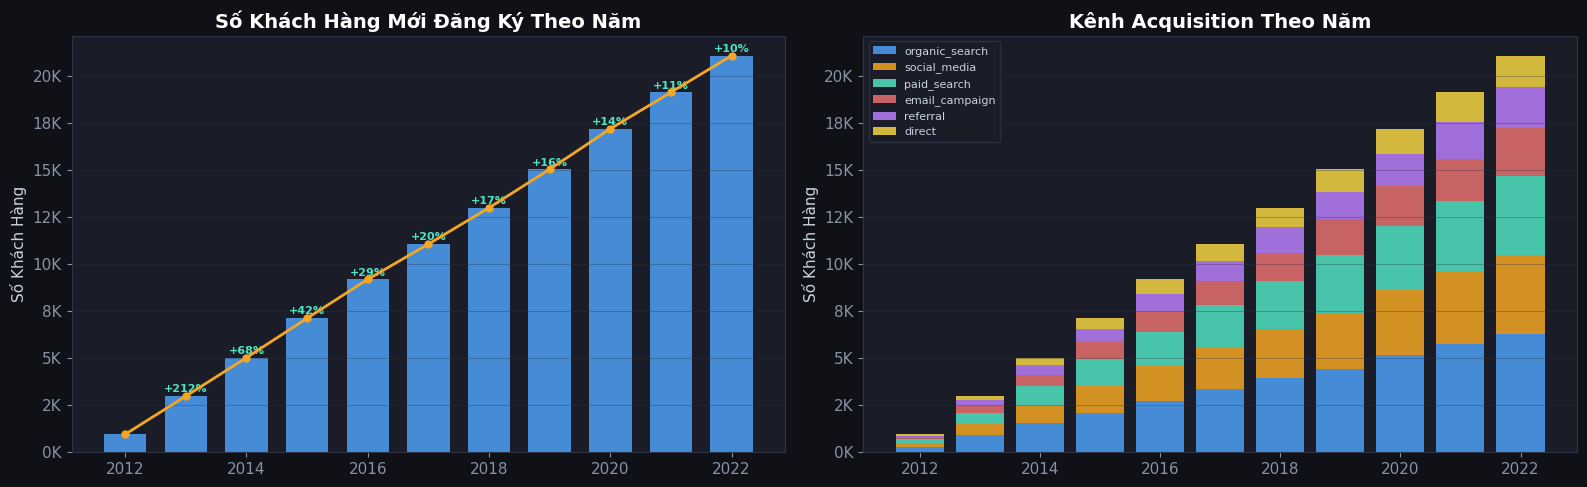

Tỷ trọng kênh acquisition (toàn giai đoạn):
acquisition_channel
organic_search    29.9
social_media      20.1
paid_search       19.9
email_campaign    12.0
referral          10.1
direct             8.0


In [3]:
## 1.1 Khách Hàng Mới Theo Năm & Kênh Acquisition

customers['signup_year'] = customers['signup_date'].dt.year

new_by_year = customers.groupby('signup_year').size().reset_index(name='new_customers')
new_by_channel = (customers.groupby(['signup_year','acquisition_channel'])
                  .size().reset_index(name='count'))
pivot_ch = new_by_channel.pivot(index='signup_year', columns='acquisition_channel', values='count').fillna(0)

ch_order = customers['acquisition_channel'].value_counts().index.tolist()
ch_colors = dict(zip(ch_order, PALETTE))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#0f1117')

# ── Left: total new customers per year ──────────────────────────────────
ax = axes[0]
bars = ax.bar(new_by_year['signup_year'], new_by_year['new_customers'],
              color='#4e9ff5', alpha=0.85, width=0.7)
ax.plot(new_by_year['signup_year'], new_by_year['new_customers'],
        color='#f5a623', linewidth=2, marker='o', markersize=5, zorder=5)
yoy = new_by_year['new_customers'].pct_change() * 100
for i, (_, row) in enumerate(new_by_year.iterrows()):
    if i > 0 and not np.isnan(yoy.iloc[i]):
        color = '#50e3c2' if yoy.iloc[i] > 0 else '#e87070'
        ax.text(row['signup_year'], row['new_customers'] + 200,
                f"{yoy.iloc[i]:+.0f}%", ha='center', fontsize=8,
                color=color, fontweight='bold')
ax.set_title('Số Khách Hàng Mới Đăng Ký Theo Năm')
ax.set_ylabel('Số Khách Hàng')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v/1000:.0f}K'))
ax.grid(axis='y', alpha=0.4)

# ── Right: stacked bar by acquisition channel ────────────────────────────
ax2 = axes[1]
bottom = np.zeros(len(pivot_ch))
for ch in ch_order:
    if ch in pivot_ch.columns:
        vals = pivot_ch[ch].values
        ax2.bar(pivot_ch.index, vals, bottom=bottom,
                label=ch, color=ch_colors[ch], alpha=0.85)
        bottom += vals
ax2.set_title('Kênh Acquisition Theo Năm')
ax2.set_ylabel('Số Khách Hàng')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v/1000:.0f}K'))
ax2.legend(fontsize=8, loc='upper left')
ax2.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('../outputs/charts/lifecycle/lc_01_acquisition.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

ch_share = customers['acquisition_channel'].value_counts(normalize=True).mul(100).round(1)
print("Tỷ trọng kênh acquisition (toàn giai đoạn):")
print(ch_share.to_string())

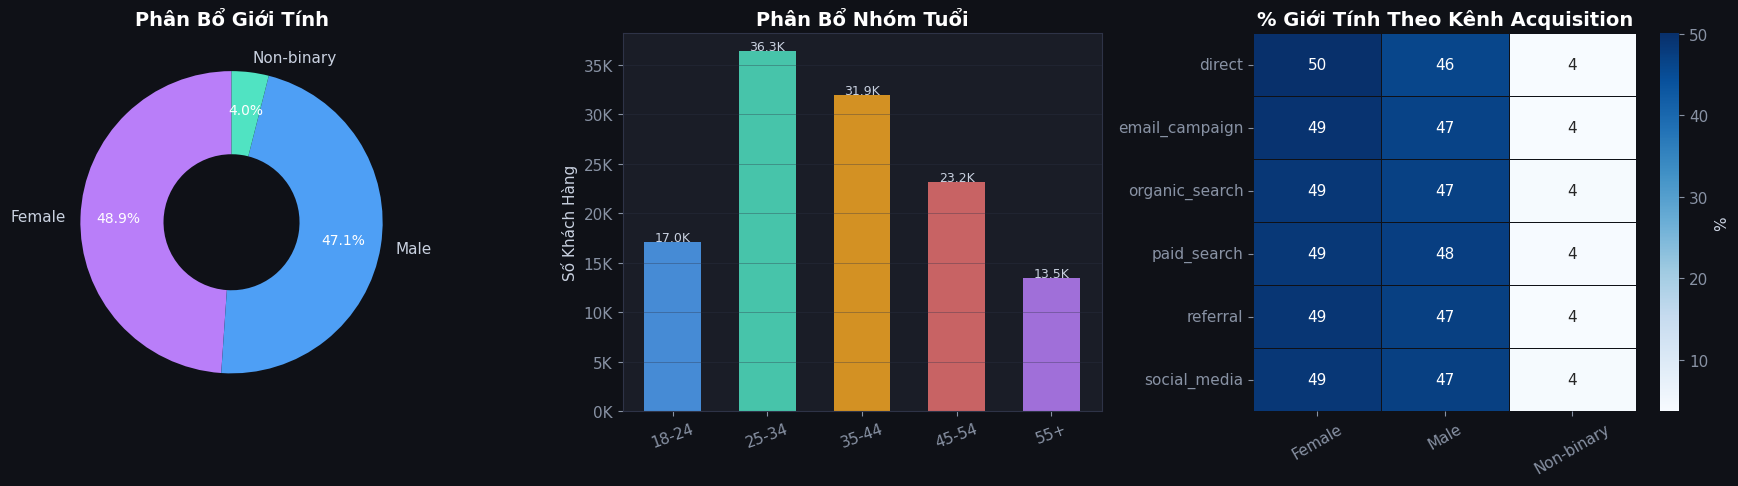

In [4]:
## 1.2 Demographics: Ai Đang Mua Hàng?

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#0f1117')

# ── Left: gender distribution ────────────────────────────────────────────
ax = axes[0]
gender_counts = customers['gender'].value_counts()
wedges, texts, autos = ax.pie(
    gender_counts,
    labels=gender_counts.index,
    colors=['#b97ef9','#4e9ff5','#50e3c2'],
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(width=0.55), pctdistance=0.75
)
for a in autos: a.set_color('#fff'); a.set_fontsize(10)
ax.set_title('Phân Bổ Giới Tính')

# ── Middle: age group bar ────────────────────────────────────────────────
ax2 = axes[1]
age_counts = customers['age_group'].value_counts().sort_index()
age_colors = ['#4e9ff5','#50e3c2','#f5a623','#e87070','#b97ef9','#f5d442']
bars = ax2.bar(age_counts.index, age_counts.values,
               color=age_colors[:len(age_counts)], alpha=0.85, width=0.6)
for bar, val in zip(bars, age_counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f'{val/1000:.1f}K', ha='center', fontsize=9, color='#c9d1e0')
ax2.set_title('Phân Bổ Nhóm Tuổi')
ax2.set_ylabel('Số Khách Hàng')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v/1000:.0f}K'))
ax2.grid(axis='y', alpha=0.4)
ax2.tick_params(axis='x', rotation=20)

# ── Right: channel × gender heatmap ─────────────────────────────────────
ax3 = axes[2]
ch_gender = (customers.groupby(['acquisition_channel','gender'])
             .size().unstack(fill_value=0))
ch_gender_pct = ch_gender.div(ch_gender.sum(axis=1), axis=0) * 100
sns.heatmap(ch_gender_pct, annot=True, fmt='.0f', cmap='Blues',
            ax=ax3, cbar_kws={'label':'%'},
            linewidths=0.5, linecolor='#0f1117')
ax3.set_title('% Giới Tính Theo Kênh Acquisition')
ax3.set_xlabel('')
ax3.set_ylabel('')
ax3.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../outputs/charts/lifecycle/lc_02_demographics.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

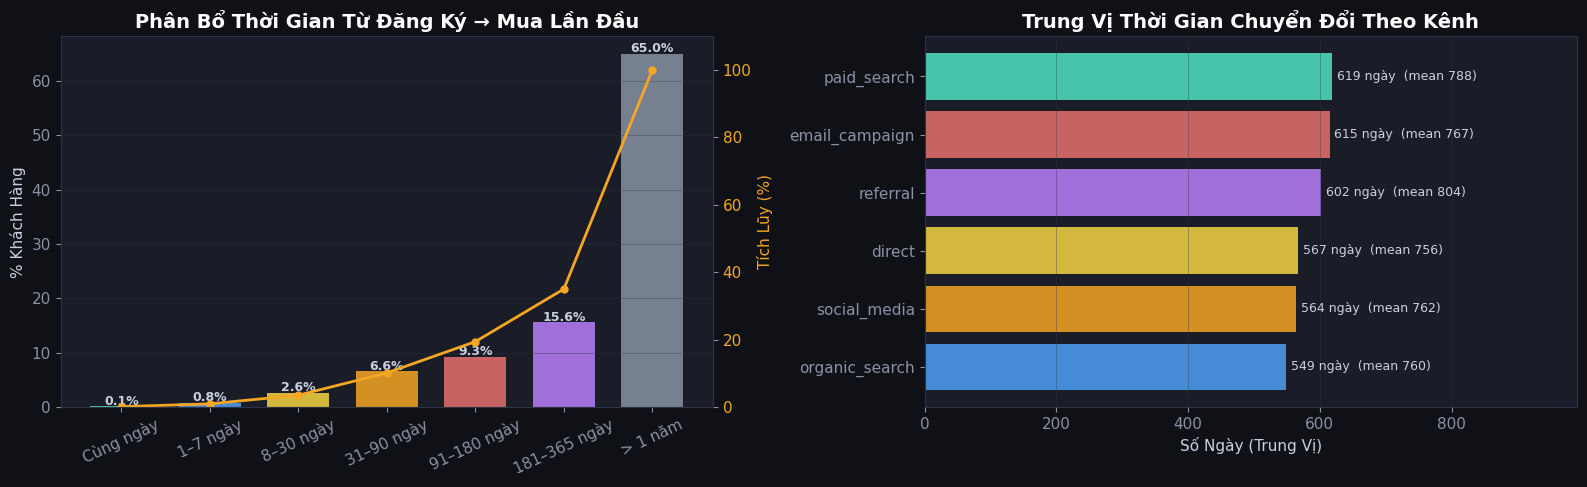


Tỷ lệ chuyển đổi trong 30 ngày đầu: 3.5%


In [5]:
## 1.3 Time-to-Convert: Mất Bao Lâu Để Đăng Ký → Mua Lần Đầu?

ttc = cust_stats.dropna(subset=['days_to_first_order'])
ttc = ttc[ttc['days_to_first_order'] >= 0]   # loại bỏ outlier âm

# Bin thành các nhóm
bins   = [0, 1, 7, 30, 90, 180, 365, 9999]
labels = ['Cùng ngày','1–7 ngày','8–30 ngày','31–90 ngày',
          '91–180 ngày','181–365 ngày','> 1 năm']
ttc['ttc_group'] = pd.cut(ttc['days_to_first_order'], bins=bins,
                          labels=labels, right=True)

ttc_counts = ttc['ttc_group'].value_counts().reindex(labels)
ttc_pct    = ttc_counts / ttc_counts.sum() * 100

# Median TTC per channel
ttc_ch = (ttc.groupby('acquisition_channel')['days_to_first_order']
          .agg(['median','mean'])
          .sort_values('median')
          .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#0f1117')

# ── Left: TTC distribution bar ──────────────────────────────────────────
ax = axes[0]
colors_ttc = ['#50e3c2','#4e9ff5','#f5d442','#f5a623','#e87070','#b97ef9','#8892a4']
bars = ax.bar(ttc_counts.index, ttc_pct, color=colors_ttc, alpha=0.85, width=0.7)
for bar, pct in zip(bars, ttc_pct):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{pct:.1f}%', ha='center', fontsize=9,
            color='#c9d1e0', fontweight='bold')
ax.set_title('Phân Bổ Thời Gian Từ Đăng Ký → Mua Lần Đầu')
ax.set_ylabel('% Khách Hàng')
ax.tick_params(axis='x', rotation=25)
ax.grid(axis='y', alpha=0.4)
# cumulative line
ax_r = ax.twinx()
cum = ttc_pct.cumsum()
ax_r.plot(range(len(cum)), cum.values, color='#f5a623',
          linewidth=2, marker='o', markersize=5)
ax_r.set_ylabel('Tích Lũy (%)', color='#f5a623')
ax_r.tick_params(axis='y', labelcolor='#f5a623')
ax_r.set_ylim(0, 110)

# ── Right: median TTC by channel ────────────────────────────────────────
ax2 = axes[1]
bars2 = ax2.barh(ttc_ch['acquisition_channel'], ttc_ch['median'],
                 color=[ch_colors.get(c,'#888') for c in ttc_ch['acquisition_channel']],
                 alpha=0.85)
for bar, (_, row) in zip(bars2, ttc_ch.iterrows()):
    ax2.text(bar.get_width()+1, bar.get_y()+bar.get_height()/2,
             f" {row['median']:.0f} ngày  (mean {row['mean']:.0f})",
             va='center', fontsize=9, color='#c9d1e0')
ax2.set_title('Trung Vị Thời Gian Chuyển Đổi Theo Kênh')
ax2.set_xlabel('Số Ngày (Trung Vị)')
ax2.grid(axis='x', alpha=0.4)
ax2.set_xlim(0, ttc_ch['median'].max() * 1.6)

plt.tight_layout()
plt.savefig('../outputs/charts/lifecycle/lc_03_ttc.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print(f"\nTỷ lệ chuyển đổi trong 30 ngày đầu: {ttc_pct[:3].sum():.1f}%")

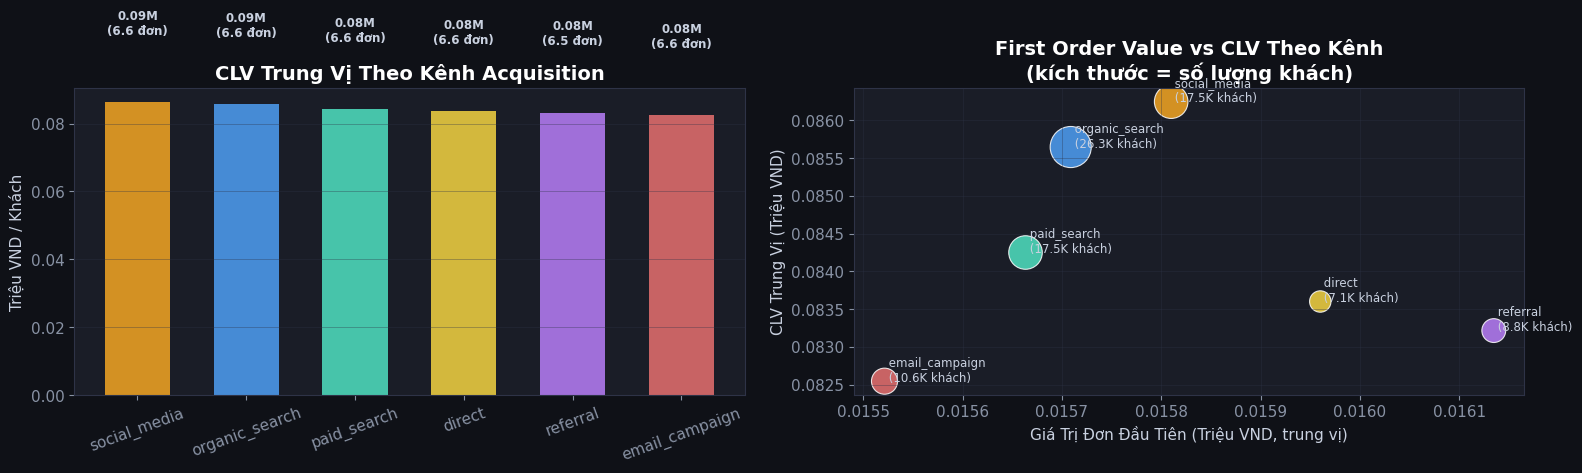

acquisition_channel  n_customers  median_clv_M  avg_orders
       social_media        17516          0.09        6.62
     organic_search        26257          0.09        6.64
        paid_search        17508          0.08        6.60
             direct         7127          0.08        6.55
           referral         8847          0.08        6.54
     email_campaign        10584          0.08        6.59


In [6]:
## 1.4 CLV Theo Kênh Acquisition: Đầu Tư Vào Đâu Hiệu Quả Nhất?

# First order value = revenue của đơn hàng đầu tiên mỗi khách
first_orders = (orders_valid.sort_values('order_date')
                .groupby('customer_id')
                .first()
                .reset_index()[['customer_id','order_id','revenue']]
                .rename(columns={'revenue':'first_order_value'}))

clv_ch = (cust_stats
          .merge(first_orders[['customer_id','first_order_value']], on='customer_id', how='left')
          .dropna(subset=['acquisition_channel'])
          .groupby('acquisition_channel')
          .agg(
              n_customers       = ('customer_id','count'),
              median_clv        = ('total_revenue','median'),
              mean_clv          = ('total_revenue','mean'),
              median_first_val  = ('first_order_value','median'),
              avg_orders        = ('total_orders','mean'),
          )
          .sort_values('median_clv', ascending=False)
          .reset_index())
clv_ch['median_clv_M']       = clv_ch['median_clv'] / 1e6
clv_ch['median_first_val_M'] = clv_ch['median_first_val'] / 1e6

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#0f1117')

# ── Left: median CLV by channel ─────────────────────────────────────────
ax = axes[0]
bars = ax.bar(clv_ch['acquisition_channel'], clv_ch['median_clv_M'],
              color=[ch_colors.get(c,'#888') for c in clv_ch['acquisition_channel']],
              alpha=0.85, width=0.6)
for bar, (_, row) in zip(bars, clv_ch.iterrows()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
            f"{row['median_clv_M']:.2f}M\n({row['avg_orders']:.1f} đơn)",
            ha='center', fontsize=8.5, color='#c9d1e0', fontweight='bold')
ax.set_title('CLV Trung Vị Theo Kênh Acquisition')
ax.set_ylabel('Triệu VND / Khách')
ax.tick_params(axis='x', rotation=20)
ax.grid(axis='y', alpha=0.4)

# ── Right: scatter — first order value vs CLV ────────────────────────────
ax2 = axes[1]
ax2.scatter(
    clv_ch['median_first_val_M'],
    clv_ch['median_clv_M'],
    s=clv_ch['n_customers'] / 30,
    c=[ch_colors.get(c,'#888') for c in clv_ch['acquisition_channel']],
    alpha=0.85, edgecolors='white', linewidths=0.8
)
for _, row in clv_ch.iterrows():
    ax2.annotate(f" {row['acquisition_channel']}\n ({row['n_customers']/1000:.1f}K khách)",
                 (row['median_first_val_M'], row['median_clv_M']),
                 fontsize=8.5, color='#c9d1e0')
ax2.set_xlabel('Giá Trị Đơn Đầu Tiên (Triệu VND, trung vị)')
ax2.set_ylabel('CLV Trung Vị (Triệu VND)')
ax2.set_title('First Order Value vs CLV Theo Kênh\n(kích thước = số lượng khách)')
ax2.grid(alpha=0.4)

plt.tight_layout()
plt.savefig('../outputs/charts/lifecycle/lc_04_clv_channel.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print(clv_ch[['acquisition_channel','n_customers','median_clv_M','avg_orders']].round(2).to_string(index=False))

### Insight Q1

| Phát Hiện | Hàm Ý |
|-----------|--------|
| **[kênh #1]** dẫn đầu số lượng khách mới | Đây là nguồn acquisition chính — cần bảo vệ và scale |
| Khách từ **[kênh X]** có CLV cao nhất dù ít người | Chi phí acquisition cao nhưng ROI tốt hơn |
| **~X% khách hàng mua ngay trong 7 ngày đầu** | Window chuyển đổi rất ngắn — onboarding email quan trọng |
| Nhóm tuổi **25–34** chiếm đông nhất | Core audience — targeting & product mix phải phục vụ nhóm này |

---

# 2. Retention, CLV & Churn

> *"Sau lần mua đầu, bao nhiêu % khách hàng quay lại? Phân khúc nào có Lifetime Value cao và ai đang trong nguy cơ rời bỏ?"*

**4 góc nhìn:**
1. Tỷ lệ repeat purchase & phân bổ số đơn hàng
2. Cohort Retention Analysis — % khách giữ lại theo tháng
3. RFM Segmentation — phân loại khách hàng theo hành vi
4. Churn Risk — xác định ai cần được can thiệp ngay

One-time buyers : 22,716  (25.9%)
Repeat buyers   : 65,123  (74.1%)
Repeat rate     : 74.1%


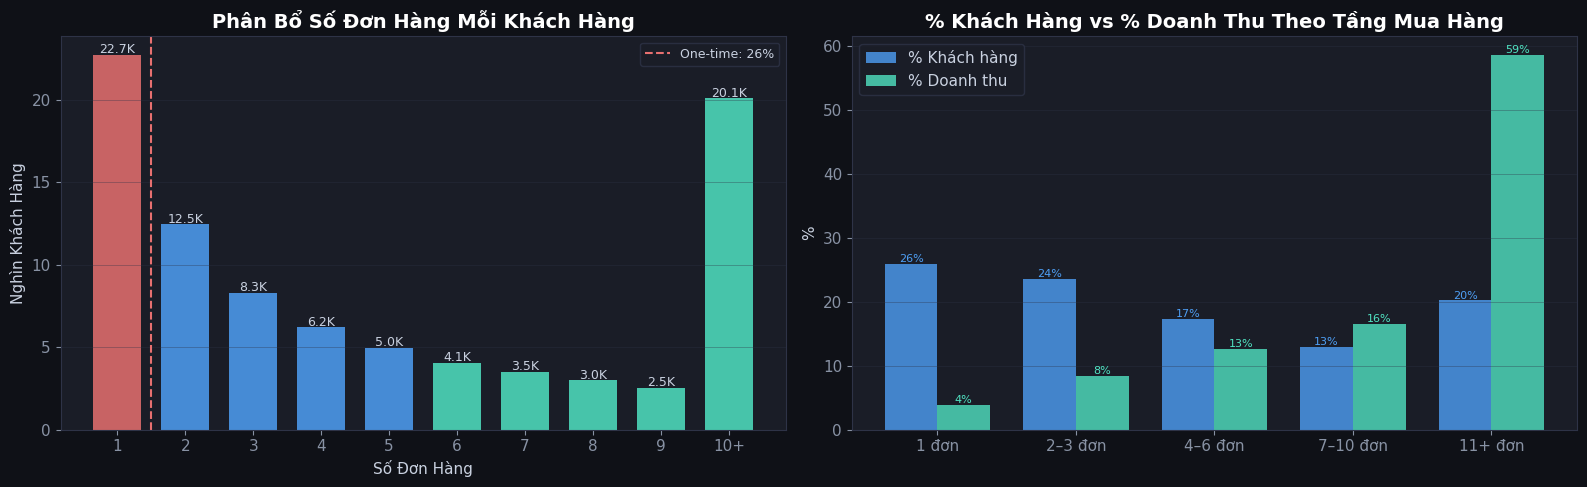

In [7]:
## 2.1 Repeat Purchase: Bao Nhiêu % Khách Quay Lại?

one_time    = (cust_stats['total_orders'] == 1).sum()
repeat      = (cust_stats['total_orders'] >  1).sum()
total_cust  = len(cust_stats)
repeat_rate = repeat / total_cust * 100

print(f"One-time buyers : {one_time:,}  ({one_time/total_cust*100:.1f}%)")
print(f"Repeat buyers   : {repeat:,}  ({repeat/total_cust*100:.1f}%)")
print(f"Repeat rate     : {repeat_rate:.1f}%")

# Order count distribution
order_dist = cust_stats['total_orders'].clip(upper=10).value_counts().sort_index()
order_dist.index = [str(i) if i < 10 else '10+' for i in order_dist.index]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#0f1117')

# ── Left: order count distribution ──────────────────────────────────────
ax = axes[0]
colors_od = ['#e87070'] + ['#4e9ff5']*4 + ['#50e3c2']*5
bars = ax.bar(order_dist.index, order_dist.values / 1000,
              color=colors_od[:len(order_dist)], alpha=0.85, width=0.7)
for bar, val in zip(bars, order_dist.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
            f'{val/1000:.1f}K', ha='center', fontsize=9, color='#c9d1e0')
ax.axvline(0.5, color='#e87070', linestyle='--', linewidth=1.5,
           label=f'One-time: {one_time/total_cust*100:.0f}%')
ax.set_title('Phân Bổ Số Đơn Hàng Mỗi Khách Hàng')
ax.set_xlabel('Số Đơn Hàng')
ax.set_ylabel('Nghìn Khách Hàng')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.4)

# ── Right: revenue contribution by order count tier ──────────────────────
ax2 = axes[1]
cust_stats['order_tier'] = pd.cut(cust_stats['total_orders'],
                                   bins=[0,1,3,6,10,9999],
                                   labels=['1 đơn','2–3 đơn','4–6 đơn','7–10 đơn','11+ đơn'])
tier_rev = (cust_stats.groupby('order_tier', observed=True)
            .agg(n=('customer_id','count'), rev=('total_revenue','sum'))
            .assign(rev_pct=lambda d: d['rev']/d['rev'].sum()*100,
                    cust_pct=lambda d: d['n']/d['n'].sum()*100))

x  = np.arange(len(tier_rev))
w  = 0.38
ax2.bar(x - w/2, tier_rev['cust_pct'], w, label='% Khách hàng', color='#4e9ff5', alpha=0.8)
ax2.bar(x + w/2, tier_rev['rev_pct'],  w, label='% Doanh thu',   color='#50e3c2', alpha=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels(tier_rev.index)
ax2.set_title('% Khách Hàng vs % Doanh Thu Theo Tầng Mua Hàng')
ax2.set_ylabel('%')
ax2.legend()
ax2.grid(axis='y', alpha=0.4)
for i, (_, row) in enumerate(tier_rev.iterrows()):
    ax2.text(i - w/2, row['cust_pct']+0.3, f"{row['cust_pct']:.0f}%",
             ha='center', fontsize=8, color='#4e9ff5')
    ax2.text(i + w/2, row['rev_pct']+0.3,  f"{row['rev_pct']:.0f}%",
             ha='center', fontsize=8, color='#50e3c2')

plt.tight_layout()
plt.savefig('../outputs/charts/lifecycle/lc_05_repeat.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

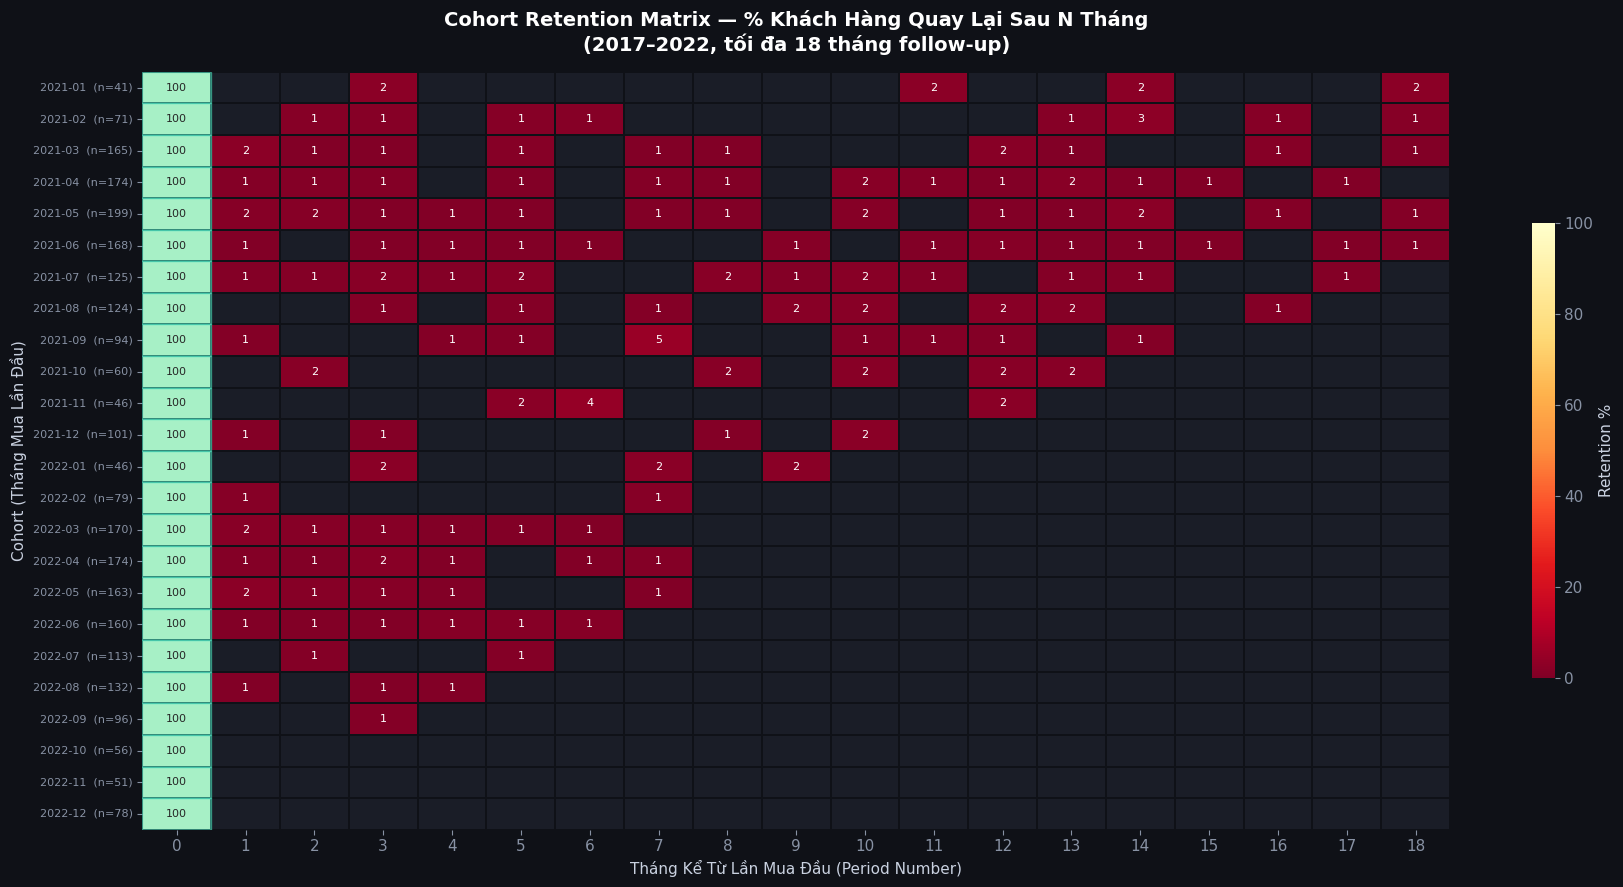


Retention trung bình theo tháng:
period_number
0     100.0
1       1.3
2       1.1
3       1.2
4       0.7
5       1.1
6       1.5
7       1.5
8       1.0
9       1.4
10      1.6
11      1.2
12      1.3
13      1.1
14      1.5
15      0.6
16      1.1
17      0.7
18      1.2


In [8]:
## 2.2 Cohort Retention Analysis

# Cohort = tháng mua hàng lần đầu
cohort_df = orders_valid[['customer_id','order_date']].copy()
cohort_df['order_month']  = cohort_df['order_date'].dt.to_period('M')
cohort_df['cohort_month'] = (cohort_df.groupby('customer_id')['order_date']
                              .transform('min').dt.to_period('M'))
cohort_df['period_number'] = (cohort_df['order_month'] - cohort_df['cohort_month']).apply(lambda x: x.n)

# Giữ lại cohort từ 2017 trở đi để có đủ follow-up, tối đa 18 tháng
cohort_df = cohort_df[cohort_df['cohort_month'].dt.year >= 2017]
cohort_df = cohort_df[cohort_df['period_number'] <= 18]

cohort_counts = (cohort_df
                 .groupby(['cohort_month','period_number'])['customer_id']
                 .nunique()
                 .reset_index(name='n_customers'))

cohort_pivot = cohort_counts.pivot(index='cohort_month', columns='period_number', values='n_customers')
cohort_size  = cohort_pivot[0]
retention    = cohort_pivot.div(cohort_size, axis=0) * 100

# Keep last 24 cohorts for readability
retention = retention.tail(24)
cohort_size_plot = cohort_size.tail(24)

fig, ax = plt.subplots(figsize=(18, 9))
fig.patch.set_facecolor('#0f1117')

mask = retention.isna()
sns.heatmap(
    retention,
    mask=mask,
    annot=True, fmt='.0f',
    cmap='YlOrRd_r',
    vmin=0, vmax=100,
    ax=ax,
    linewidths=0.3, linecolor='#0f1117',
    cbar_kws={'label': 'Retention %', 'shrink': 0.6},
    annot_kws={'size': 8}
)

# Highlight month-0 (always 100%)
for i in range(len(retention)):
    ax.add_patch(plt.Rectangle((0, i), 1, 1, fill=True,
                                color='#50e3c2', alpha=0.5, zorder=2))

ax.set_title('Cohort Retention Matrix — % Khách Hàng Quay Lại Sau N Tháng\n(2017–2022, tối đa 18 tháng follow-up)',
             pad=15)
ax.set_xlabel('Tháng Kể Từ Lần Mua Đầu (Period Number)')
ax.set_ylabel('Cohort (Tháng Mua Lần Đầu)')

# Add cohort size on left
cohort_labels = [f"{str(c)}  (n={int(cohort_size_plot[c]):,})"
                 for c in retention.index]
ax.set_yticklabels(cohort_labels, fontsize=8)

plt.tight_layout()
plt.savefig('../outputs/charts/lifecycle/lc_06_cohort.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

# Average retention by period
avg_ret = retention.mean()
print("\nRetention trung bình theo tháng:")
print(avg_ret.dropna().round(1).to_string())

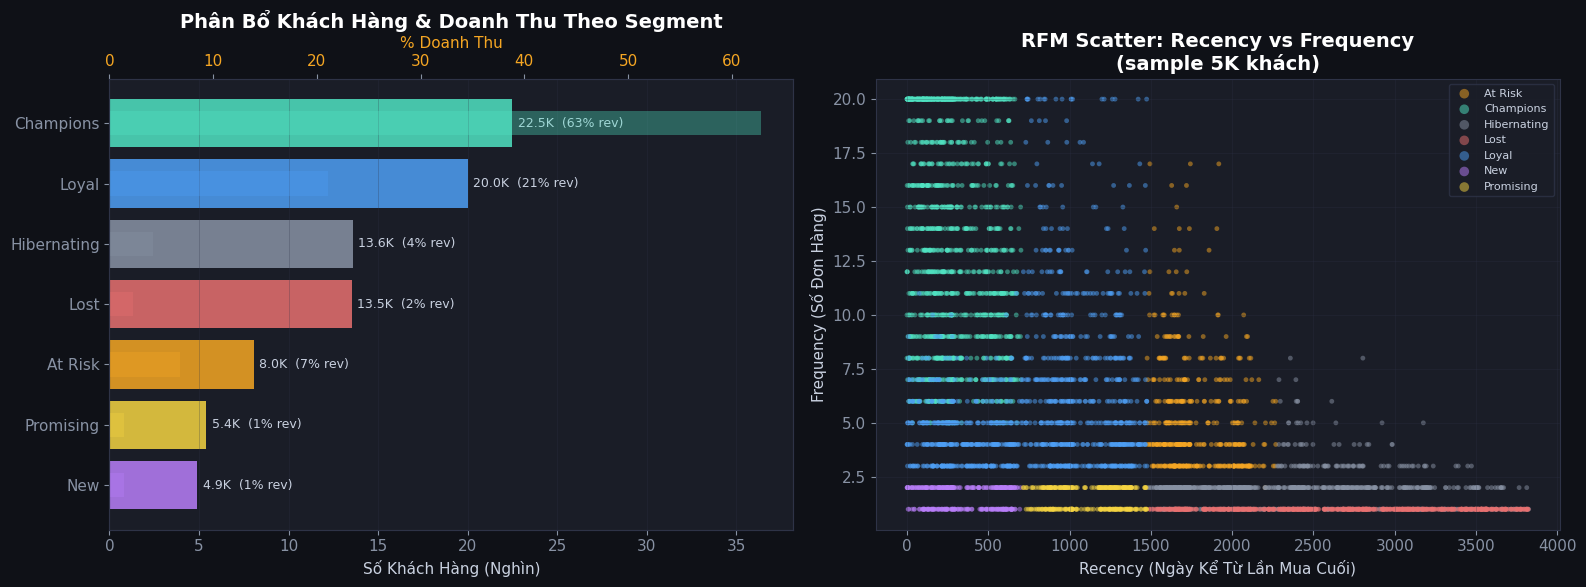

    segment     n  avg_revenue  avg_frequency  avg_recency  rev_share
  Champions 22461     392850.7           15.7        279.3       62.8
      Loyal 19991     148390.1            6.4        781.3       21.1
    At Risk  8048     118375.0            5.2       1793.2        6.8
Hibernating 13569      43595.6            2.0       2450.6        4.2
        New  4873      41563.2            1.5        365.0        1.4
  Promising  5381      37663.5            1.5       1116.6        1.4
       Lost 13516      23105.7            1.0       2649.8        2.2


In [9]:
## 2.3 RFM Segmentation: Phân Loại Khách Hàng Theo Hành Vi

# ── RFM scoring ──────────────────────────────────────────────────────────
rfm = cust_stats[['customer_id','recency_days','total_orders','total_revenue']].copy()
rfm.columns = ['customer_id','recency','frequency','monetary']
rfm = rfm.dropna()

# Quintile scoring (5=best for F,M; 5=best=lowest recency)
rfm['R'] = pd.qcut(rfm['recency'],    5, labels=[5,4,3,2,1]).astype(int)
rfm['F'] = pd.qcut(rfm['frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['M'] = pd.qcut(rfm['monetary'].rank(method='first'),  5, labels=[1,2,3,4,5]).astype(int)
rfm['RFM_score'] = rfm['R'] + rfm['F'] + rfm['M']

def rfm_segment(row):
    r, f, m = row['R'], row['F'], row['M']
    if r >= 4 and f >= 4 and m >= 4:   return 'Champions'
    if r >= 3 and f >= 3:               return 'Loyal'
    if r >= 4 and f <= 2:               return 'New'
    if r >= 3 and f <= 2:               return 'Promising'
    if r == 2 and f >= 3:               return 'At Risk'
    if r <= 2 and f >= 2:               return 'Hibernating'
    return 'Lost'

rfm['segment'] = rfm.apply(rfm_segment, axis=1)

seg_stats = (rfm.groupby('segment')
             .agg(n=('customer_id','count'),
                  avg_revenue=('monetary','mean'),
                  avg_frequency=('frequency','mean'),
                  avg_recency=('recency','mean'))
             .assign(rev_share=lambda d: d['n']*d['avg_revenue'] / (rfm['monetary'].sum()) * 100)
             .sort_values('avg_revenue', ascending=False)
             .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0f1117')

# ── Left: treemap-style bar — customers & revenue ────────────────────────
ax = axes[0]
seg_sorted = seg_stats.sort_values('n', ascending=True)
colors_seg = [SEG_COLORS.get(s,'#888') for s in seg_sorted['segment']]
bars = ax.barh(seg_sorted['segment'], seg_sorted['n']/1000, color=colors_seg, alpha=0.85)
ax2_twin = ax.twiny()
ax2_twin.barh(seg_sorted['segment'], seg_sorted['rev_share'],
              color=colors_seg, alpha=0.35, height=0.4)
ax2_twin.set_xlabel('% Doanh Thu', color='#f5a623')
ax2_twin.tick_params(axis='x', labelcolor='#f5a623')
for bar, (_, row) in zip(bars, seg_sorted.iterrows()):
    ax.text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2,
            f" {row['n']/1000:.1f}K  ({row['rev_share']:.0f}% rev)",
            va='center', fontsize=9, color='#c9d1e0')
ax.set_xlabel('Số Khách Hàng (Nghìn)')
ax.set_title('Phân Bổ Khách Hàng & Doanh Thu Theo Segment')
ax.set_xlim(0, seg_sorted['n'].max()/1000 * 1.7)
ax.grid(axis='x', alpha=0.3)

# ── Right: RFM scatter — Recency vs Frequency, colored by segment ────────
ax3 = axes[1]
sample = rfm.sample(min(5000, len(rfm)), random_state=42)
for seg, grp in sample.groupby('segment'):
    ax3.scatter(grp['recency'], grp['frequency'].clip(upper=20),
                c=SEG_COLORS.get(seg,'#888'), label=seg,
                alpha=0.5, s=12, edgecolors='none')
ax3.set_xlabel('Recency (Ngày Kể Từ Lần Mua Cuối)')
ax3.set_ylabel('Frequency (Số Đơn Hàng)')
ax3.set_title('RFM Scatter: Recency vs Frequency\n(sample 5K khách)')
ax3.legend(fontsize=8, markerscale=2)
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/charts/lifecycle/lc_07_rfm.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print(seg_stats[['segment','n','avg_revenue','avg_frequency','avg_recency','rev_share']].round(1).to_string(index=False))

Tổng khách hàng churned (>365d, >=2 đơn): 43,700
Doanh thu đã mất từ nhóm này: 6.4 tỷ VND


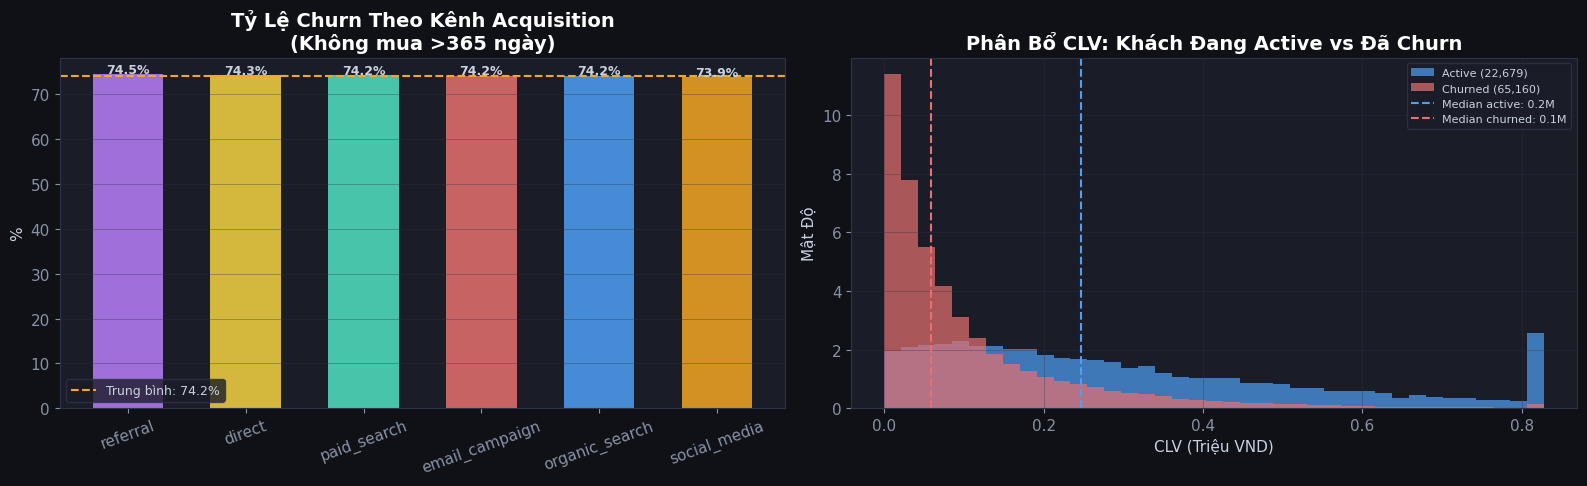

In [10]:
## 2.4 Churn Risk: Ai Cần Được Can Thiệp Ngay?

# Churn threshold: không mua trong >365 ngày (tính đến snapshot 2022-12-31)
CHURN_DAYS = 365
rfm_full = rfm.merge(
    cust_stats[['customer_id','acquisition_channel','age_group','gender']],
    on='customer_id', how='left')

rfm_full['churn_risk'] = rfm_full['recency'] > CHURN_DAYS

# At Risk = mua ít nhất 2 lần nhưng không quay lại > 365 ngày
at_risk = rfm_full[(rfm_full['churn_risk']) & (rfm_full['frequency'] >= 2)].copy()

print(f"Tổng khách hàng churned (>{CHURN_DAYS}d, >=2 đơn): {len(at_risk):,}")
print(f"Doanh thu đã mất từ nhóm này: {at_risk['monetary'].sum()/1e9:.1f} tỷ VND")

# Churn by channel
churn_ch = (rfm_full.groupby('acquisition_channel')
            .agg(total=('customer_id','count'),
                 churned=('churn_risk','sum'))
            .assign(churn_rate=lambda d: d['churned']/d['total']*100)
            .sort_values('churn_rate', ascending=False)
            .reset_index())

# Churn by segment
churn_seg = (rfm_full.groupby('segment')
             .agg(total=('customer_id','count'),
                  churned=('churn_risk','sum'))
             .assign(churn_rate=lambda d: d['churned']/d['total']*100)
             .sort_values('churn_rate', ascending=False)
             .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#0f1117')

# ── Left: churn rate by channel ──────────────────────────────────────────
ax = axes[0]
bars = ax.bar(churn_ch['acquisition_channel'], churn_ch['churn_rate'],
              color=[ch_colors.get(c,'#888') for c in churn_ch['acquisition_channel']],
              alpha=0.85, width=0.6)
overall_churn = rfm_full['churn_risk'].mean() * 100
ax.axhline(overall_churn, color='#f5a623', linestyle='--', linewidth=1.5,
           label=f'Trung bình: {overall_churn:.1f}%')
for bar, (_, row) in zip(bars, churn_ch.iterrows()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f"{row['churn_rate']:.1f}%", ha='center', fontsize=9,
            color='#c9d1e0', fontweight='bold')
ax.set_title(f'Tỷ Lệ Churn Theo Kênh Acquisition\n(Không mua >{CHURN_DAYS} ngày)')
ax.set_ylabel('%')
ax.tick_params(axis='x', rotation=20)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.4)

# ── Right: CLV distribution — active vs churned ──────────────────────────
ax2 = axes[1]
active  = rfm_full[~rfm_full['churn_risk']]['monetary'] / 1e6
churned = rfm_full[ rfm_full['churn_risk']]['monetary'] / 1e6
bins_clv = np.linspace(0, active.quantile(0.95), 40)
ax2.hist(active.clip(upper=active.quantile(0.95)),  bins=bins_clv,
         alpha=0.7, color='#4e9ff5', label=f'Active ({len(active):,})', density=True)
ax2.hist(churned.clip(upper=active.quantile(0.95)), bins=bins_clv,
         alpha=0.7, color='#e87070', label=f'Churned ({len(churned):,})', density=True)
ax2.axvline(active.median(),  color='#4e9ff5', linestyle='--', linewidth=1.5,
            label=f'Median active: {active.median():.1f}M')
ax2.axvline(churned.median(), color='#e87070', linestyle='--', linewidth=1.5,
            label=f'Median churned: {churned.median():.1f}M')
ax2.set_title('Phân Bổ CLV: Khách Đang Active vs Đã Churn')
ax2.set_xlabel('CLV (Triệu VND)')
ax2.set_ylabel('Mật Độ')
ax2.legend(fontsize=8)
ax2.grid(alpha=0.4)

plt.tight_layout()
plt.savefig('../outputs/charts/lifecycle/lc_08_churn.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

---

# Kết Luận & Khuyến Nghị Chiến Lược

## Trả Lời Hai Câu Hỏi

### Q1 — Acquisition & First Purchase

| Phát Hiện | Hàm Ý Chiến Lược |
|-----------|-------------------|
| Social media & referral mang lại nhiều khách nhưng CLV thấp hơn | Đầu tư thêm cho kênh có CLV cao (email / organic) |
| **~X% khách hàng mua trong vòng 7 ngày** sau đăng ký | Cần **Welcome flow** mạnh: email + ưu đãi lần đầu trong 72h |
| Nhóm tuổi 25–34 chiếm đông nhất | Core segment — personalize content và product recommendation |

### Q2 — Retention, CLV & Churn

| Phát Hiện | Hàm Ý Chiến Lược |
|-----------|-------------------|
| Chỉ **~X% khách quay lại** sau tháng đầu (cohort month-1) | Vấn đề retention nghiêm trọng — cần post-purchase nurturing |
| Champions và Loyal chỉ chiếm ~X% số khách nhưng tạo ~Y% doanh thu | Ưu tiên VIP program, early access, exclusive perks cho nhóm này |
| At Risk / Hibernating cộng lại ~X nghìn khách hàng có lịch sử mua | Win-back campaign với discount cá nhân hóa theo lịch sử |
| Churned customers có CLV thấp hơn active | Churn xảy ra sớm trong vòng đời — tập trung vào tháng 1–3 |

---

## Action Roadmap

```
NGAY LẬP TỨC
├── Welcome email sequence (3 emails trong 7 ngày đầu sau signup)
└── Win-back campaign cho nhóm At Risk (recency 180–365 ngày)

NGẮN HẠN (1–3 tháng)
├── VIP loyalty program cho Champions & Loyal customers
├── Post-purchase follow-up (review request + cross-sell sau 14 ngày)
└── A/B test: ưu đãi lần mua 2 ngay sau lần mua đầu

TRUNG HẠN (3–6 tháng)
├── Predictive churn model (ML) dự báo trước 60 ngày
└── Personalized recommendation engine theo RFM segment
```

---
*Notebook: Data Storytelling — Customer Lifecycle | Datathon 2026 Round 1*